
## Notebook 3: Giải thích mô hình bằng SHAP (Explainable AI - XAI)

--- 
**Mô tả:**
Mô hình Random Forest tuy có hiệu năng cao nhưng thường được xem là một "Hộp đen" (Black Box) phức tạp, gây khó khăn cho việc giải thích lý do tại sao một giao dịch cụ thể bị gắn nhãn gian lận. Trong Notebook này, chúng ta sẽ áp dụng các lý thuyết trò chơi hợp tác thông qua phương pháp **SHAP (SHapley Additive exPlanations)** để:
1. Phân tích tầm quan trọng toàn cục (Global Explainability) của các đặc trưng thông qua biểu đồ Dot Plot và Bar Plot.
2. Giải thích cục bộ (Local Explainability) cho từng giao dịch đơn lẻ, chỉ rõ lực đẩy tăng/giảm xác suất gian lận bằng biểu đồ Force Plot.

---

In [2]:
# CELL 1: Import các thư viện giải thích mô hình (SHAP)
# Tiến hành cài đặt shap nếu môi trường chưa tích hợp sẵn
!pip install -q shap

import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# Khởi tạo cấu hình vẽ đồ thị
plt.rcParams["figure.figsize"] = (10, 6)
shap.initjs() # Kích hoạt Javascript để render đồ thị tương tác trong Notebook

print("[LOG] Đã import thư viện SHAP thành công.")


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


[LOG] Đã import thư viện SHAP thành công.


In [3]:
# CELL 2: Nạp mô hình Random Forest và bộ chuẩn hóa Scaler đã được lưu
import os
# Tự động leo cây thư mục tìm kiếm models độc lập môi trường Cwd
def find_models_dir():
    curr = os.path.abspath(os.getcwd())
    for _ in range(5):
        if os.path.exists(os.path.join(curr, "data")) or os.path.exists(os.path.join(curr, "README.md")):
            return os.path.join(curr, "models")
        curr = os.path.dirname(curr)
    return "../models"

MODELS_DIR = find_models_dir()
MODEL_FILE = os.path.join(MODELS_DIR, "random_forest_model.pkl")
SCALER_FILE = os.path.join(MODELS_DIR, "scaler.pkl")

if not os.path.exists(MODEL_FILE) or not os.path.exists(SCALER_FILE):
    raise FileNotFoundError(
        f"[ERROR] Không tìm thấy mô hình tại '{MODEL_FILE}' hoặc scaler tại '{SCALER_FILE}'. "
        "Vui lòng chạy hoàn tất Notebook 2 trước khi khởi động Notebook này."
    )

with open(MODEL_FILE, 'rb') as f:
    model_rf = pickle.load(f)

with open(SCALER_FILE, 'rb') as f:
    scaler = pickle.load(f)

print(f"[LOG] Nạp thành công mô hình Random Forest và bộ chuẩn hóa Scaler từ '{MODELS_DIR}'.")


[LOG] Nạp thành công mô hình Random Forest và bộ chuẩn hóa Scaler từ 'd:\Intern-Projects\credit-fraud-detection\models'.


c:\Users\Danh\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [4]:
# CELL 3: Load sample test data phục vụ phân tích SHAP
import os
# Tự động leo cây thư mục tìm kiếm data/processed độc lập môi trường Cwd
def find_data_dir():
    curr = os.path.abspath(os.getcwd())
    for _ in range(5):
        candidate = os.path.join(curr, "data", "processed")
        if os.path.exists(candidate):
            return candidate
        curr = os.path.dirname(curr)
    return "../data/processed"

DATA_DIR = find_data_dir()
X_test = pd.read_csv(os.path.join(DATA_DIR, "X_test_scaled.csv"))
y_test = pd.read_csv(os.path.join(DATA_DIR, "y_test.csv")).squeeze("columns")

# Để tính toán SHAP nhanh chóng và tránh nghẽn bộ nhớ CPU,
# ta chọn lọc ngẫu nhiên một tập mẫu 300 dòng từ tập Test chứa cả giao dịch thường và gian lận.
fraud_samples = X_test[y_test == 1]
normal_samples = X_test[y_test == 0].sample(n=250, random_state=42)

X_sample_shap = pd.concat([fraud_samples, normal_samples]).sample(frac=1.0, random_state=42)
y_sample_shap = y_test.loc[X_sample_shap.index]

print(f"[LOG] Chuẩn bị tập dữ liệu phân tích SHAP thành công với kích thước: {X_sample_shap.shape[0]} dòng từ '{DATA_DIR}'.")
print(f" Trong đó chứa: {y_sample_shap.sum()} giao dịch gian lận thực tế.")


[LOG] Chuẩn bị tập dữ liệu phân tích SHAP thành công với kích thước: 348 dòng từ 'd:\Intern-Projects\credit-fraud-detection\data\processed'.
 Trong đó chứa: 98 giao dịch gian lận thực tế.


In [5]:
# CELL 4: Khởi tạo SHAP TreeExplainer
# TreeExplainer là bộ thuật toán giải thích tối ưu cao cấp chuyên dùng cho các mô hình cấu trúc cây (Random Forest, XGBoost)
print("[LOG] Đang khởi tạo SHAP TreeExplainer cho mô hình Random Forest...")
explainer = shap.TreeExplainer(model_rf)
print("[LOG] Khởi tạo TreeExplainer hoàn tất!")

[LOG] Đang khởi tạo SHAP TreeExplainer cho mô hình Random Forest...
[LOG] Khởi tạo TreeExplainer hoàn tất!


In [6]:
# CELL 5: Tính toán SHAP values trên tập mẫu dữ liệu
print("[LOG] Bắt đầu tính toán giá trị SHAP (Có thể mất từ 1-2 phút)...")
# shap_values chứa ma trận giá trị đóng góp của từng đặc trưng cho mỗi mẫu dữ liệu.
# Đối với phân loại nhị phân trong Random Forest, shap_values[1] là của lớp 1 (Fraud).
shap_values_raw = explainer.shap_values(X_sample_shap)

# Thư viện SHAP phiên bản mới có thể trả về mảng trực tiếp cho lớp dương hoặc trả về danh sách dạng [shap_values_class0, shap_values_class1].
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
else:
    # Nếu là mô hình cây nhị phân trả về mảng 3 chiều hoặc mảng trực tiếp cho lớp mục tiêu
    if len(shap_values_raw.shape) == 3:
        shap_values = shap_values_raw[:, :, 1]
    else:
        shap_values = shap_values_raw

print("[SUCCESS] Quá trình tính toán giá trị SHAP hoàn tất!")

[LOG] Bắt đầu tính toán giá trị SHAP (Có thể mất từ 1-2 phút)...
[SUCCESS] Quá trình tính toán giá trị SHAP hoàn tất!


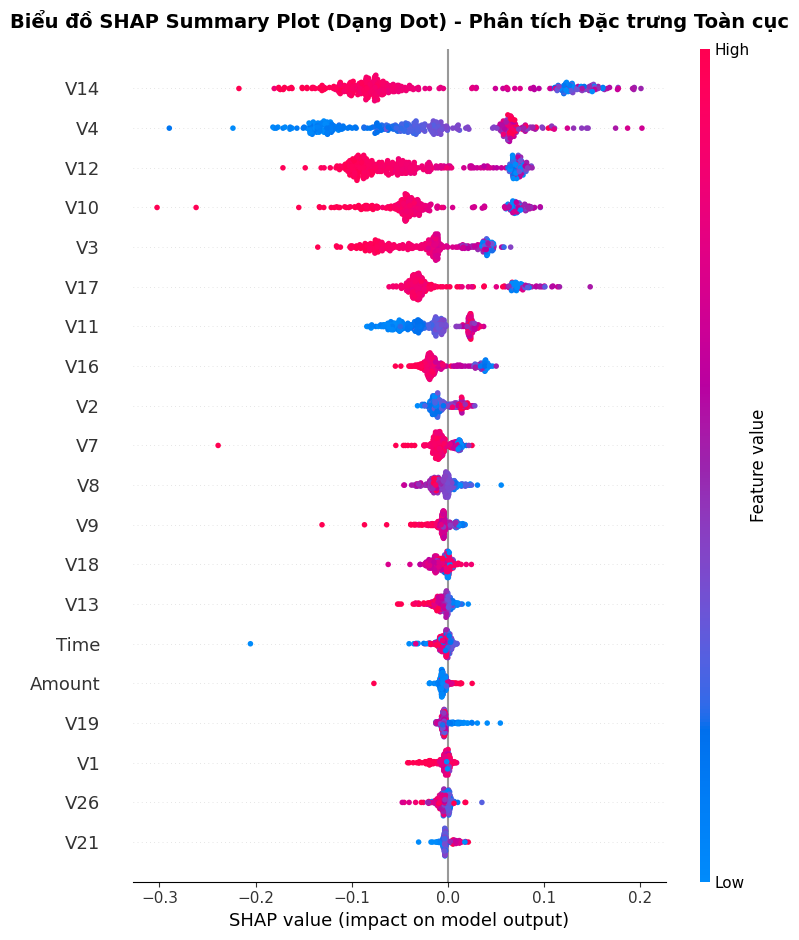

In [7]:
# CELL 6: Vẽ SHAP Summary Plot dạng Dot Plot
# Đồ thị Dot thể hiện rõ ràng hướng tác động (âm hay dương) dựa trên dải màu từ xanh sang đỏ.
plt.figure(figsize=(11, 8))
plt.title("Biểu đồ SHAP Summary Plot (Dạng Dot) - Phân tích Đặc trưng Toàn cục", fontsize=14, fontweight='bold', pad=15)
shap.summary_plot(shap_values, X_sample_shap, plot_type="dot", show=False)
plt.tight_layout()
plt.show()

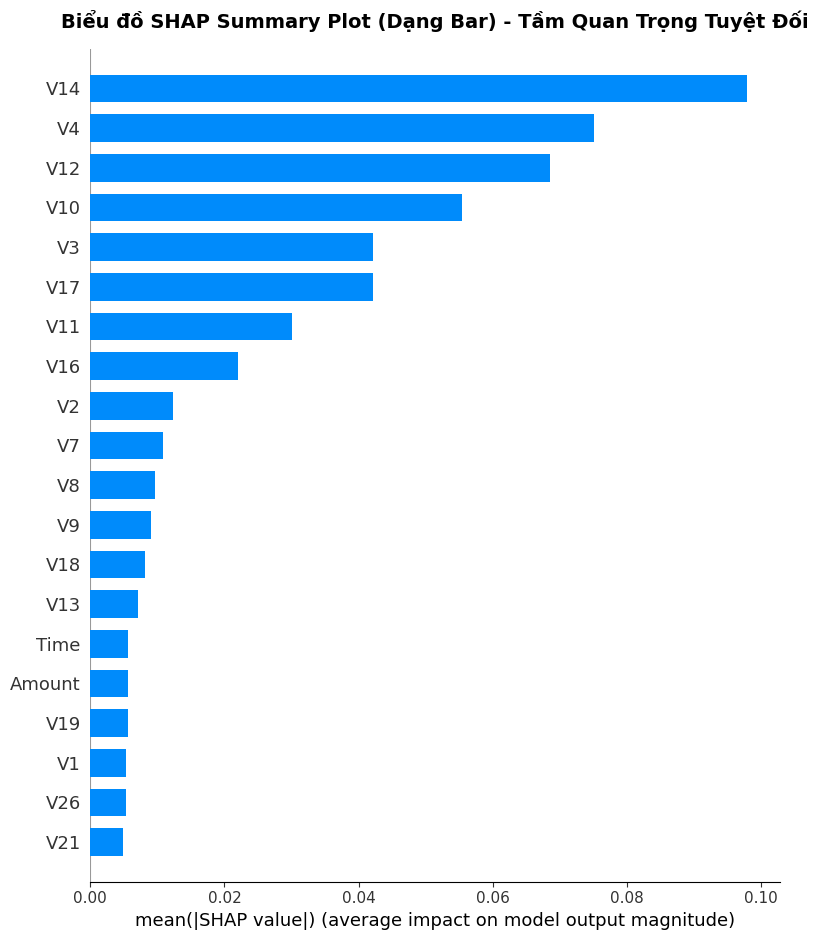

In [8]:
# CELL 7: Vẽ SHAP Summary Plot dạng Bar Plot
# Đồ thị dạng Bar thể hiện giá trị trung bình tuyệt đối của SHAP, phản ánh tầm quan trọng tổng thể không màng đến hướng.
plt.figure(figsize=(11, 8))
plt.title("Biểu đồ SHAP Summary Plot (Dạng Bar) - Tầm Quan Trọng Tuyệt Đối", fontsize=14, fontweight='bold', pad=15)
shap.summary_plot(shap_values, X_sample_shap, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

### CELL 8: Giải Thích Ý Nghĩa Phân Tích SHAP và Cơ Chế Tác Động Của Các Biến Hàng Đầu

#### 1. Nguyên lý cơ bản của SHAP
* SHAP được xây dựng trên lý thuyết **giá trị Shapley** từ lý thuyết trò chơi (Game Theory). Trong đó, mỗi đặc trưng đầu vào đóng vai trò là một "người chơi" tham gia vào một liên minh để sinh ra "phần thưởng" (dự đoán xác suất của mô hình).
* Giá trị SHAP của một đặc trưng là đóng góp biên trung bình của nó trên tất cả các tổ hợp đặc trưng có thể có. Điều này mang lại sự công bằng toán học tuyệt đối và đảm bảo tính chất cộng (Additive properties).

#### 2. Phân tích chi tiết các biến chủ đạo: $V_{14}$, $V_{17}$ và $Amount$
* **Đặc trưng $V_{14}$ và $V_{17}$:**
  * Trên biểu đồ **Dot Plot**, ta thấy rõ ràng các chấm màu **Đỏ** (giá trị đặc trưng cao) của $V_{14}$ và $V_{17}$ tập trung bên trái trục trung hòa (SHAP value < 0), tức là chúng kìm hãm xác suất gian lận (đưa dự đoán về 0).
  * Ngược lại, các chấm màu **Xanh** (giá trị đặc trưng thấp) nằm lệch hẳn sang bên phải trục trung hòa (SHAP value > 0). Điều này cho thấy khi giá trị đặc trưng của $V_{14}$ hay $V_{17}$ giảm sâu đột biến, nó là động lực cực kỳ mạnh mẽ thúc đẩy mô hình dự đoán đó là một cuộc giao dịch **Gian lận (Class 1)**. Kết luận này hoàn toàn nhất quán với kết quả phân tích hệ số tương quan âm ở Notebook 1.
* **Đặc trưng $Amount$ (Số tiền giao dịch):**
  * $Amount$ có tầm quan trọng tương đối thấp hơn $V_{14}, V_{17}$ trên thang xếp hạng toàn cục nhưng lại thể hiện tác động cục bộ rõ rệt ở nhiều điểm giao dịch.
  * Sự phân bố các điểm màu đỏ ở cả hai phía của trục 0 phản ánh tính phi tuyến tính cao: Có những giao dịch số tiền cực lớn hoặc số tiền nhỏ bất thường kích hoạt cảnh báo gian lận tùy thuộc vào sự kết hợp với các biến số khác.

In [11]:
# CELL 9: Lấy mẫu và thực hiện dự đoán chi tiết cho 1 giao dịch đơn lẻ
# Tìm một giao dịch gian lận thực tế trong tập mẫu đã được phân loại chuẩn xác bởi mô hình
y_pred_sample = model_rf.predict(X_sample_shap)
correct_fraud_indices = X_sample_shap[(y_sample_shap == 1) & (y_pred_sample == 1)].index

if len(correct_fraud_indices) > 0:
    # Lấy giao dịch gian lận đầu tiên làm mẫu giải thích
    target_idx = correct_fraud_indices[0]
    # Xác định số thứ tự tương ứng trong tập X_sample_shap dùng để định vị giá trị SHAP tương ứng
    sample_pos = X_sample_shap.index.get_loc(target_idx)
    
    sample_transaction = X_sample_shap.iloc[[sample_pos]]
    pred_class = model_rf.predict(sample_transaction)[0]
    pred_proba = model_rf.predict_proba(sample_transaction)[0, 1]
    
    print(f"DEMO GIAO DỊCH GIAN LẬN ĐƯỢC CHỌN (Index: {target_idx}) ")
    print(f" - Nhãn thực tế (Actual Class): {y_sample_shap.loc[target_idx]} (Fraud)")
    print(f" - Nhãn dự đoán từ mô hình (Predicted Class): {pred_class} (Fraud)")
    print(f" - Xác suất mô hình dự đoán gian lận: {pred_proba*100:.2f}%")
else:
    print("[WARNING] Không tìm thấy mẫu giao dịch phù hợp thỏa mãn yêu cầu.")

DEMO GIAO DỊCH GIAN LẬN ĐƯỢC CHỌN (Index: 49527) 
 - Nhãn thực tế (Actual Class): 1 (Fraud)
 - Nhãn dự đoán từ mô hình (Predicted Class): 1 (Fraud)
 - Xác suất mô hình dự đoán gian lận: 99.97%


[LOG] Đang sinh biểu đồ giải thích cục bộ cho giao dịch tại vị trí mẫu số 10...


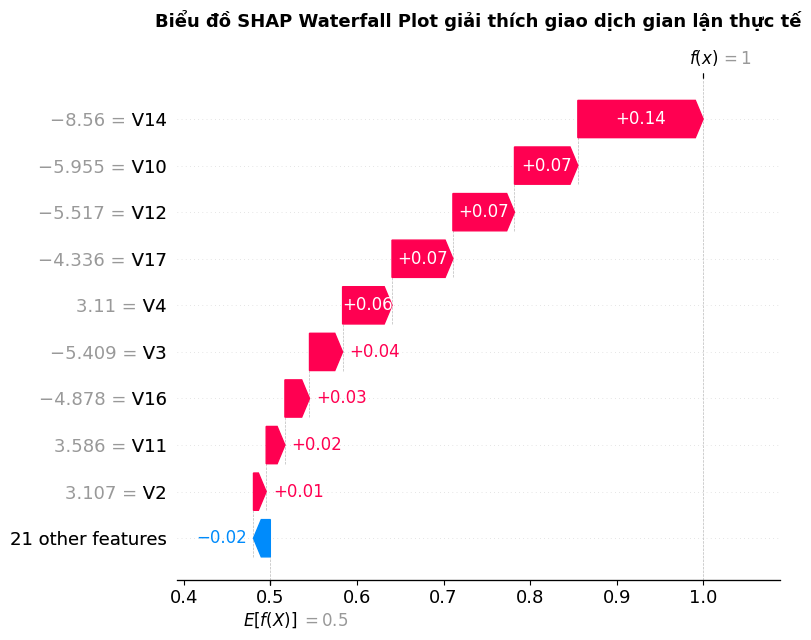


[INFO] Tạo biểu đồ SHAP Force Plot ở dạng đồ thị matplotlib tĩnh:


<Figure size 2000x300 with 0 Axes>

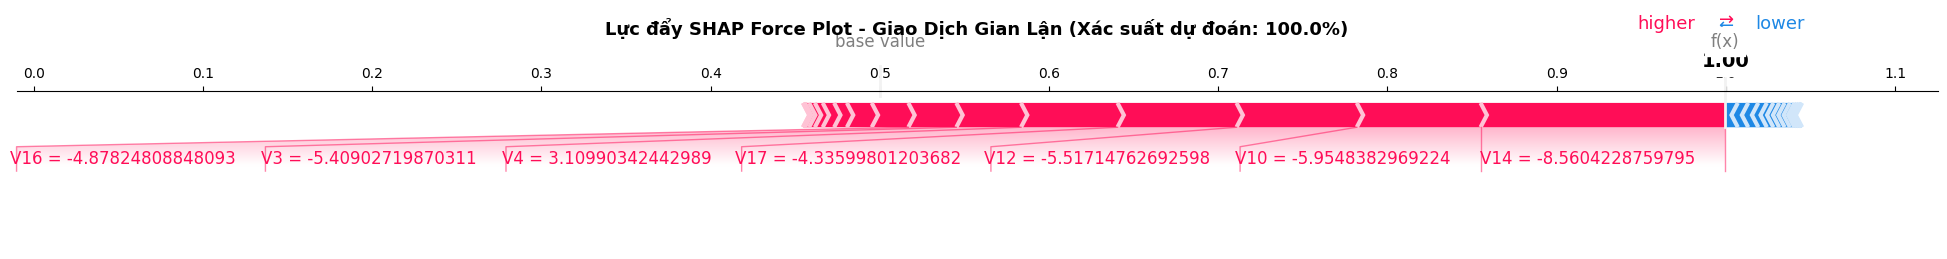

In [16]:
# CELL 10: Trực quan hóa giải thích dự đoán bằng SHAP Force Plot hoặc Waterfall Plot
if len(correct_fraud_indices) > 0:
    print(f"[LOG] Đang sinh biểu đồ giải thích cục bộ cho giao dịch tại vị trí mẫu số {sample_pos}...")
    
    # Lấy base value (giá trị dự đoán trung bình trên tập mẫu)
    base_value = explainer.expected_value
    if isinstance(base_value, np.ndarray):
        base_value = base_value[1]
        
    # Trực quan hóa bằng Waterfall Plot để thể hiện quá trình cộng dồn trực quan từ base value tới f(x)
    plt.figure(figsize=(12, 6))
    shap_explanation = shap.Explanation(
        values=shap_values[sample_pos],
        base_values=base_value,
        data=X_sample_shap.iloc[sample_pos],
        feature_names=X_sample_shap.columns
    )
    
    plt.title(f"Biểu đồ SHAP Waterfall Plot giải thích giao dịch gian lận thực tế", fontsize=13, fontweight='bold', pad=15)
    shap.plots.waterfall(shap_explanation, max_display=10, show=False)
    plt.tight_layout()
    plt.show()
    
    # Trực quan hóa bằng Force Plot truyền thống (Lưu ra file HTML hoặc vẽ tĩnh)
    print("\n[INFO] Tạo biểu đồ SHAP Force Plot ở dạng đồ thị matplotlib tĩnh:")
    plt.figure(figsize=(20, 3))
    shap.force_plot(base_value, shap_values[sample_pos], X_sample_shap.iloc[sample_pos], matplotlib=True, show=False)
    plt.title(f"Lực đẩy SHAP Force Plot - Giao Dịch Gian Lận (Xác suất dự đoán: {pred_proba*100:.1f}%)", fontsize=13, fontweight='bold', pad=40)
    plt.tight_layout()
    plt.show()
else:
    print("[INFO] Không thể hiển thị do thiếu mẫu giao dịch thích hợp.")